# Early Identification of High-Aptitude Students from Online Engagement Behaviour

**Course:** Introduction to Machine Learning — Summative Project
**Author:** Christian Tonny
**Dataset:** Open University Learning Analytics Dataset (OULAD)
**GitHub repository:** *(link in report)* &nbsp;|&nbsp; **Video demo:** *(link in report)*

## The problem I am working on

In many under-resourced schools across Africa, students with real academic talent go
unnoticed. Teachers often have large classes, little specialised training, and no tools
for spotting subject-specific strengths early — especially in STEM. By the time a strong
student is identified (usually through end-of-year exams), the window for targeted support
has already closed. My mission centres on education in underserved communities, and this
project asks a concrete question:

> **Can observable engagement behaviour, captured in the first 30 days of a course,
> predict which students will excel — before any major assessment has happened?**

If the answer is yes, then the kinds of behaviours a teacher *can* observe (how often a
student shows up, how much material they touch, how early they start) become a practical
early-warning system for talent, not just for failure.

## Why OULAD

I compared four candidate datasets (xAPI-Edu-Data, the UCI Student Performance set, and
two Kaggle student-performance sets) before settling on OULAD. The deciding factors:

- It contains `imd_band`, the UK Index of Multiple Deprivation decile for each student's
  neighbourhood. My problem statement is about underserved communities, and this is the
  only candidate where socioeconomic deprivation is actually measured rather than proxied.
- It has real behavioural data: 10.6 million clickstream rows from the virtual learning
  environment (VLE). This is the "observable behaviour" my argument depends on.
- At 32,593 student-course records it is large enough for the deep learning half of this
  project. The alternatives (480–6,607 rows, two of them synthetic) were not.
- The four-class outcome (Distinction / Pass / Fail / Withdrawn) gives a genuinely
  imbalanced classification problem — Distinction is only ~9% of records, and Distinction
  is exactly the class I care about finding.

The dataset was published by Kuzilek, Hlosta and Zdrahal (2017) and is anonymised and
openly licensed. One disclosure: I used OULAD in a previous course for a *regression*
task. This project is a different problem (multi-class early classification), uses a
feature set I engineered from scratch (early-window behavioural aggregates), and asks a
different question. The full literature review is in the written report; the short
version is that most prior OULAD work predicts dropout using the whole semester of data,
while I restrict myself to the first 30 days and focus on the high-achiever class.

## How this notebook is organised

1. Setup and reproducibility
2. Getting the data
3. First look at the raw tables
4. Building the modelling table (preprocessing + feature engineering)
5. Exploratory analysis
6. Encoding, splits and pipelines
7. Shared evaluation helpers
8. Experiments 1–8 (classical ML → deep learning → binary reformulation)
9. Consolidated results table
10. Error analysis and discussion
11. Conclusion

## 1. Setup and reproducibility

The cell below lists every dependency and installs anything missing, so the notebook
runs on a fresh Colab instance. I pin nothing exotic — everything is standard PyData
stack plus TensorFlow and imbalanced-learn (for SMOTE in Experiment 4).

All random seeds are fixed to 42: Python's `random`, NumPy, and TensorFlow (via
`tf.keras.utils.set_random_seed`, which sets all three). GPU floating-point
non-determinism can still cause tiny run-to-run differences in the neural networks,
but on CPU the results reproduce exactly.

In [1]:
import importlib.util, subprocess, sys

REQUIRED = {
    "pandas": "pandas", "numpy": "numpy", "sklearn": "scikit-learn",
    "matplotlib": "matplotlib", "seaborn": "seaborn",
    "tensorflow": "tensorflow", "imblearn": "imbalanced-learn",
}
missing = [pkg for mod, pkg in REQUIRED.items() if importlib.util.find_spec(mod) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("Installed:", ", ".join(missing))
else:
    print("All dependencies already present.")

All dependencies already present.


In [2]:
import os, random, warnings, zipfile, urllib.request
from pathlib import Path

os.environ["PYTHONHASHSEED"] = "42"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # hide TF info logs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

import sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, roc_curve, auc,
                             classification_report, confusion_matrix, recall_score)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", font_scale=0.9)

print("python     :", sys.version.split()[0])
print("pandas     :", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("tensorflow :", tf.__version__)

/Users/tonny/Dev-ML/summartive-intro-to-ml/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


python     : 3.9.6
pandas     : 2.3.3
scikit-learn: 1.6.1
tensorflow : 2.20.0


## 2. Getting the data

The original OULAD download endpoint at `analyse.kmi.open.ac.uk` no longer works, so I
use the UCI Machine Learning Repository mirror (dataset #349). The zip is about 47 MB
and expands to seven CSV tables, the largest being the 450 MB clickstream. The cell
checks for an existing local copy first so re-runs cost nothing.

In [3]:
DATA_DIR = Path("dataset_exploration/oulad")
if not (DATA_DIR / "studentInfo.csv").exists():
    DATA_DIR = Path("oulad_data")
    DATA_DIR.mkdir(exist_ok=True)
    zip_path = DATA_DIR / "oulad.zip"
    if not zip_path.exists():
        url = ("https://archive.ics.uci.edu/static/public/349/"
               "open+university+learning+analytics+dataset.zip")
        print("Downloading OULAD from UCI (~47 MB)...")
        urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(DATA_DIR)
print("Data directory:", DATA_DIR.resolve())
for f in sorted(DATA_DIR.glob("*.csv")):
    print(f"  {f.name:28s} {f.stat().st_size/1e6:8.1f} MB")

Data directory: /Users/tonny/Dev-ML/summartive-intro-to-ml/dataset_exploration/oulad
  assessments.csv                   0.0 MB
  courses.csv                       0.0 MB
  studentAssessment.csv             5.7 MB
  studentInfo.csv                   3.5 MB
  studentRegistration.csv           1.1 MB
  studentVle.csv                  453.8 MB
  vle.csv                           0.3 MB


## 3. First look at the raw tables

OULAD is relational: demographics live in `studentInfo`, registration dates in
`studentRegistration`, assessment marks in `studentAssessment` (+ `assessments` for
deadlines and weights), and every click on every course material in `studentVle`
(+ `vle` describing what each material is). One important detail I found while
exploring: the UCI export uses `?` as its missing-value marker, which silently turns
numeric columns into strings unless you pass `na_values="?"` to every read.

In [4]:
student_info = pd.read_csv(DATA_DIR / "studentInfo.csv", na_values="?")
registration = pd.read_csv(DATA_DIR / "studentRegistration.csv", na_values="?")
assessments  = pd.read_csv(DATA_DIR / "assessments.csv", na_values="?")
stud_assess  = pd.read_csv(DATA_DIR / "studentAssessment.csv", na_values="?")
vle_meta     = pd.read_csv(DATA_DIR / "vle.csv", na_values="?")

print(f"studentInfo        : {student_info.shape}")
print(f"studentRegistration: {registration.shape}")
print(f"assessments        : {assessments.shape}")
print(f"studentAssessment  : {stud_assess.shape}")
print(f"vle (materials)    : {vle_meta.shape}")
student_info.head()

studentInfo        : (32593, 12)
studentRegistration: (32593, 5)
assessments        : (206, 6)
studentAssessment  : (173912, 5)
vle (materials)    : (6364, 6)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


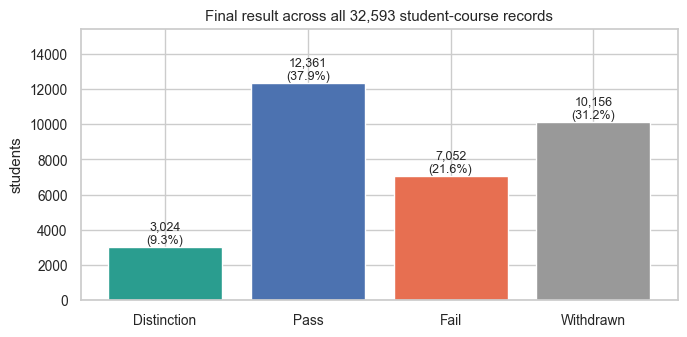

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.5))
order = ["Distinction", "Pass", "Fail", "Withdrawn"]
counts = student_info["final_result"].value_counts().reindex(order)
ax.bar(order, counts.values, color=["#2a9d8f", "#4C72B0", "#e76f51", "#999999"])
for i, v in enumerate(counts.values):
    ax.text(i, v + 200, f"{v:,}\n({v/len(student_info)*100:.1f}%)", ha="center", fontsize=9)
ax.set_ylim(0, counts.max() * 1.25)
ax.set_title("Final result across all 32,593 student-course records")
ax.set_ylabel("students")
plt.tight_layout(); plt.show()

The class imbalance is the defining feature of this problem. Distinction — the class my
whole project is about finding — is only 9.3% of records, while Pass alone is nearly 38%.
A model that never predicts Distinction can still look respectable on accuracy, so from
the start I treat macro-F1 and per-class recall as the metrics that matter, with accuracy
reported mostly for context. Withdrawn (31%) is also worth a caution: withdrawal is often
driven by life circumstances rather than ability, so I expect it to be the noisiest class.

## 4. Building the modelling table

This is the heart of the preprocessing work. The design decision that defines the whole
project: **I only use information available in the first 30 days of each course.**
That is what "early identification" means here — at day 30 a teacher could still
intervene, while a model that needs the whole semester is just an autopsy.

Concretely, the function below:

1. Streams the 10.6M-row clickstream in 2M-row chunks (it does not fit comfortably in
   Colab RAM otherwise) and keeps only clicks with `date < 30`. Negative dates are real —
   they are clicks made between registration and the official course start, and I keep
   them because engaging *before* day 0 is exactly the kind of initiative I want to capture.
2. Aggregates clicks per student-course into: total clicks, distinct active days,
   distinct materials touched, day of first access, clicks per week (weeks 1–4), and
   clicks split by the seven most common activity types (forums, content pages, quizzes...).
3. Computes a **weekly trend slope** from the four weekly totals — is this student's
   engagement rising or fading? Two students with identical totals can be on very
   different trajectories.
4. Adds early assessment behaviour: mean score, number of submissions, and mean
   *earliness* (days between submission and deadline) for anything submitted before day 30.
5. Merges demographics and registration, then **excludes students who withdrew before
   day 30** — predicting an outcome for someone who already left is not early
   identification of anything.

Two data-quality fixes I found during exploration: `imd_band` has 1,111 missing values
plus one mislabelled category (`10-20` missing its `%`), and `date_registration` is
missing for a handful of records. The result is cached to `oulad_early30.csv` so the
expensive clickstream pass runs once.

In [6]:
EARLY_DAYS = 30
KEYS = ["code_module", "code_presentation", "id_student"]
TOP_ACTIVITIES = ["forumng", "oucontent", "homepage", "quiz", "resource", "subpage", "url"]
CACHE = Path("oulad_early30.csv")


def aggregate_early_clicks(data_dir, early_days):
    """Stream studentVle in chunks, keep first-`early_days` rows, aggregate per student-course."""
    dtypes = {"code_module": "category", "code_presentation": "category",
              "id_student": "int32", "id_site": "int32", "date": "int16", "sum_click": "int16"}
    early_rows = []
    for chunk in pd.read_csv(data_dir / "studentVle.csv", dtype=dtypes, chunksize=2_000_000):
        early_rows.append(chunk[chunk["date"] < early_days])
    ev = pd.concat(early_rows, ignore_index=True)
    print(f"  clickstream rows in first {early_days} days: {len(ev):,}")

    base = ev.groupby(KEYS, observed=True).agg(
        total_clicks=("sum_click", "sum"),
        active_days=("date", "nunique"),
        distinct_materials=("id_site", "nunique"),
        first_access=("date", "min"),
    )

    ev["week"] = (ev["date"].clip(lower=0) // 7).clip(0, 3)
    weekly = (ev.groupby(KEYS + ["week"], observed=True)["sum_click"].sum()
                .unstack(fill_value=0)
                .rename(columns={i: f"week{i+1}_clicks" for i in range(4)}))
    for i in range(4):                       # make sure all four columns exist
        if f"week{i+1}_clicks" not in weekly.columns:
            weekly[f"week{i+1}_clicks"] = 0
    # least-squares slope over the 4 weekly totals (x = 0..3, denominator = 5)
    w = [weekly[f"week{i+1}_clicks"] for i in range(4)]
    weekly["click_trend"] = (-1.5 * w[0] - 0.5 * w[1] + 0.5 * w[2] + 1.5 * w[3]) / 5.0

    meta = pd.read_csv(data_dir / "vle.csv", na_values="?")[["id_site", "activity_type"]]
    ev = ev.merge(meta, on="id_site", how="left")
    ev["activity"] = np.where(ev["activity_type"].isin(TOP_ACTIVITIES),
                              ev["activity_type"], "other")
    by_act = (ev.groupby(KEYS + ["activity"], observed=True)["sum_click"].sum()
                .unstack(fill_value=0)
                .add_prefix("clicks_"))
    return base.join(weekly).join(by_act).reset_index()


def aggregate_early_assessments(data_dir, early_days):
    """Mean score, submission count and mean earliness for work submitted before day 30."""
    sa = pd.read_csv(data_dir / "studentAssessment.csv", na_values="?")
    ass = pd.read_csv(data_dir / "assessments.csv", na_values="?")
    sa = sa.merge(ass[["id_assessment", "code_module", "code_presentation", "date"]],
                  on="id_assessment")
    early = sa[sa["date_submitted"] < early_days].copy()
    early["earliness"] = early["date"] - early["date_submitted"]
    return early.groupby(KEYS).agg(
        early_score_mean=("score", "mean"),
        early_n_assess=("score", "size"),
        early_submit_lead=("earliness", "mean"),
    ).reset_index()


def build_early_table(data_dir, early_days=EARLY_DAYS, cache=CACHE):
    if cache.exists():
        print(f"Loading cached table from {cache}")
        return pd.read_csv(cache)
    print("Building modelling table from raw OULAD files...")
    clicks = aggregate_early_clicks(data_dir, early_days)
    early_assess = aggregate_early_assessments(data_dir, early_days)

    info = pd.read_csv(data_dir / "studentInfo.csv", na_values="?")
    reg = pd.read_csv(data_dir / "studentRegistration.csv", na_values="?")
    df = (info.merge(reg, on=KEYS, how="left")
              .merge(clicks, on=KEYS, how="left")
              .merge(early_assess, on=KEYS, how="left"))

    # exclude students who withdrew before the observation window closed
    before = len(df)
    df = df[~(df["date_unregistration"] < early_days)].copy()
    print(f"  excluded {before - len(df):,} students who withdrew before day {early_days}")

    # fix the mislabelled IMD category found during exploration
    df["imd_band"] = df["imd_band"].str.replace("10-20", "10-20%", regex=False)

    df.to_csv(cache, index=False)
    print(f"  saved {df.shape[0]:,} rows x {df.shape[1]} cols to {cache}")
    return df


df = build_early_table(DATA_DIR)
print(f"\nModelling table: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(3)

Loading cached table from oulad_early30.csv



Modelling table: 27,526 rows x 34 columns


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,clicks_homepage,clicks_other,clicks_oucontent,clicks_quiz,clicks_resource,clicks_subpage,clicks_url,early_score_mean,early_n_assess,early_submit_lead
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,47.0,0.0,285.0,0.0,9.0,22.0,1.0,78.0,1.0,1.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,132.0,0.0,183.0,0.0,5.0,59.0,30.0,70.0,1.0,-3.0
2,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,99.0,1.0,188.0,0.0,10.0,53.0,19.0,72.0,1.0,2.0


### Missing values and how I handle each one

Imputation choices should follow from *why* a value is missing, so I check that first.

In [7]:
miss = df.isna().sum()
print(miss[miss > 0].sort_values(ascending=False).to_string())

date_unregistration    22521
early_score_mean        6940
early_submit_lead       6934
early_n_assess          6934
imd_band                1028
distinct_materials       898
first_access             898
total_clicks             898
active_days              898
clicks_url               898
clicks_subpage           898
clicks_resource          898
clicks_quiz              898
clicks_oucontent         898
clicks_other             898
clicks_homepage          898
clicks_forumng           898
week4_clicks             898
week3_clicks             898
week2_clicks             898
week1_clicks             898
click_trend              898
date_registration          7


Each gap has a different cause, so each gets a different treatment:

- **Click features** (`total_clicks`, weekly columns, activity columns...): missing means
  the student never opened the VLE in the window. That is not unknown — it is zero
  activity, and zero activity is itself a signal. I fill with 0 and add an explicit
  `no_vle_activity` flag so models can treat "never showed up" as its own pattern.
  `first_access` gets the window edge (day 30) — "as late as possible".
- **Early assessment features**: most courses simply have no deadline inside the first
  30 days, so missing here means "no assessment yet", not "scored badly". Submission
  count gets 0; mean score and earliness get the median, paired with `early_n_assess == 0`
  telling the model when the score is imputed rather than real.
- **`imd_band`** (1,111 records): deprivation data is genuinely unknown, likely students
  outside England where IMD is not computed. I impute the median band and keep an
  `imd_missing` flag — for a project about underserved communities, deleting precisely
  the students whose socioeconomic data is missing felt like the wrong call.
- **`date_unregistration`** is only present for withdrawn students (by design, not a
  gap) and is dropped from features — knowing someone unregistered at day 200 would
  leak the outcome.
- **`date_registration`** (a handful of rows): filled with 0 = "registered at course start".

On outliers: the click counts are heavily right-skewed (a few students log thousands of
clicks). Rather than delete real behaviour, I apply `log1p` to all click-count features.
Trees are indifferent to monotone transforms, but it matters for logistic regression and
the neural networks, and it lets every model share one feature matrix.

In [8]:
CLICK_COLS = (["total_clicks"] + [f"week{i}_clicks" for i in range(1, 5)]
              + [c for c in df.columns if c.startswith("clicks_")])

def engineer_features(df):
    """All imputation, flags, ordinal encodings and transforms in one reproducible place."""
    out = df.copy()

    out["no_vle_activity"] = out["total_clicks"].isna().astype(int)
    out[CLICK_COLS] = out[CLICK_COLS].fillna(0)
    out["click_trend"] = out["click_trend"].fillna(0)
    out["active_days"] = out["active_days"].fillna(0)
    out["distinct_materials"] = out["distinct_materials"].fillna(0)
    out["first_access"] = out["first_access"].fillna(EARLY_DAYS)

    out["early_n_assess"] = out["early_n_assess"].fillna(0)
    out["early_score_mean"] = out["early_score_mean"].fillna(out["early_score_mean"].median())
    out["early_submit_lead"] = out["early_submit_lead"].fillna(out["early_submit_lead"].median())

    out["registered_early_by"] = -out["date_registration"].fillna(0)

    imd_order = ["0-10%", "10-20%", "20-30%", "30-40%", "40-50%",
                 "50-60%", "60-70%", "70-80%", "80-90%", "90-100%"]
    out["imd_missing"] = out["imd_band"].isna().astype(int)
    out["imd_band_ord"] = out["imd_band"].map({b: i for i, b in enumerate(imd_order)})
    out["imd_band_ord"] = out["imd_band_ord"].fillna(out["imd_band_ord"].median())

    edu_order = {"No Formal quals": 0, "Lower Than A Level": 1, "A Level or Equivalent": 2,
                 "HE Qualification": 3, "Post Graduate Qualification": 4}
    out["education_ord"] = out["highest_education"].map(edu_order)
    out["age_ord"] = out["age_band"].map({"0-35": 0, "35-55": 1, "55<=": 2})
    out["is_stem"] = out["code_module"].isin(["CCC", "DDD", "EEE", "FFF"]).astype(int)

    for c in CLICK_COLS:                      # tame the heavy right tail
        out[c] = np.log1p(out[c])

    onehot = pd.get_dummies(out[["gender", "region", "disability", "code_module"]],
                            drop_first=True).astype(int)

    BEHAVIOUR = (CLICK_COLS + ["click_trend", "active_days", "distinct_materials",
                               "first_access", "no_vle_activity", "registered_early_by",
                               "early_score_mean", "early_n_assess", "early_submit_lead"])
    DEMOGRAPHIC = (["imd_band_ord", "imd_missing", "education_ord", "age_ord", "is_stem",
                    "num_of_prev_attempts", "studied_credits"] + list(onehot.columns))

    X = pd.concat([out[BEHAVIOUR + ["imd_band_ord", "imd_missing", "education_ord",
                                    "age_ord", "is_stem", "num_of_prev_attempts",
                                    "studied_credits"]].reset_index(drop=True),
                   onehot.reset_index(drop=True)], axis=1)
    y = out["final_result"].reset_index(drop=True)
    return X, y, BEHAVIOUR, DEMOGRAPHIC


X, y, BEHAVIOUR_COLS, DEMOGRAPHIC_COLS = engineer_features(df)
print(f"Feature matrix: {X.shape[0]:,} rows x {X.shape[1]} features")
print(f"  behavioural features : {len(BEHAVIOUR_COLS)}")
print(f"  demographic/context  : {len(DEMOGRAPHIC_COLS)}")
assert X.isna().sum().sum() == 0, "feature matrix still has missing values"
print("No missing values remain.")

Feature matrix: 27,526 rows x 49 features
  behavioural features : 22
  demographic/context  : 27
No missing values remain.


## 5. Exploratory analysis

Three views guide the modelling decisions: the class balance after exclusions, how the
numeric features relate to each other, and whether engagement actually separates the
outcome classes at all.

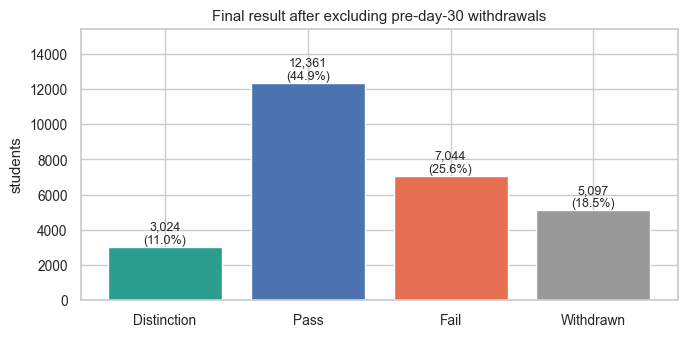

In [9]:
fig, ax = plt.subplots(figsize=(7, 3.5))
order = ["Distinction", "Pass", "Fail", "Withdrawn"]
counts = y.value_counts().reindex(order)
ax.bar(order, counts.values, color=["#2a9d8f", "#4C72B0", "#e76f51", "#999999"])
for i, v in enumerate(counts.values):
    ax.text(i, v + 200, f"{v:,}\n({v/len(y)*100:.1f}%)", ha="center", fontsize=9)
ax.set_ylim(0, counts.max() * 1.25)
ax.set_title(f"Final result after excluding pre-day-{EARLY_DAYS} withdrawals")
ax.set_ylabel("students")
plt.tight_layout(); plt.show()

Removing the ~5,000 students who left before day 30 shrinks Withdrawn from 31% to about
19%, which makes the remaining problem harder in an interesting way: the students who
withdraw *later* looked at least somewhat engaged at day 30. Distinction stays at ~11%,
still comfortably the smallest class, which is why Experiments 4 and 8 attack the
imbalance directly.

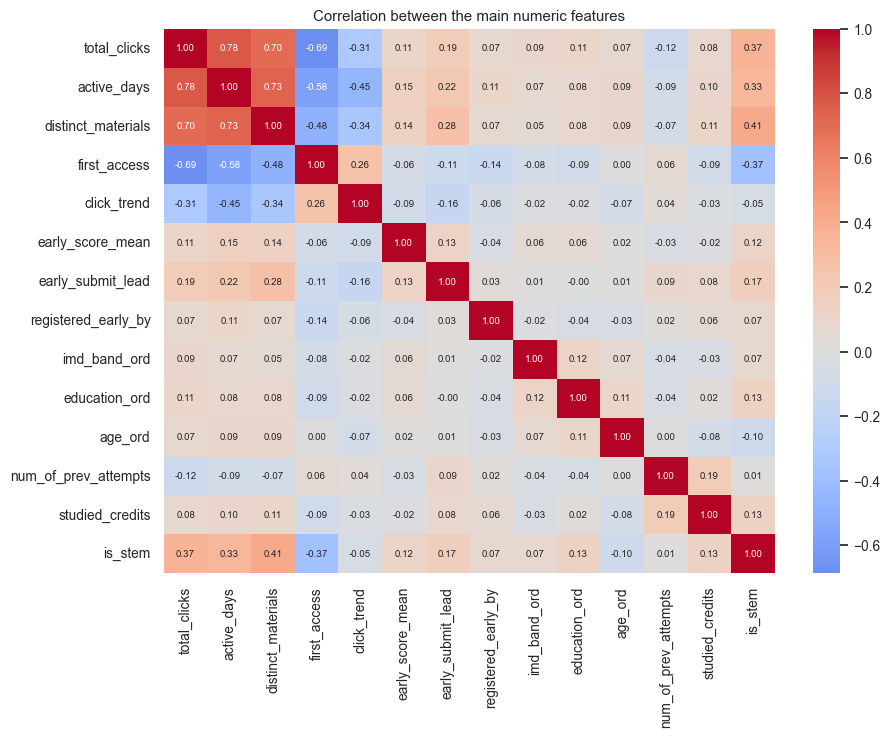

In [10]:
heat_cols = ["total_clicks", "active_days", "distinct_materials", "first_access",
             "click_trend", "early_score_mean", "early_submit_lead", "registered_early_by",
             "imd_band_ord", "education_ord", "age_ord", "num_of_prev_attempts",
             "studied_credits", "is_stem"]
fig, ax = plt.subplots(figsize=(9.5, 7.5))
sns.heatmap(X[heat_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Correlation between the main numeric features")
plt.tight_layout(); plt.show()

Two things in this heatmap shape the experiment design. First, the engagement features
correlate strongly with each other (total clicks vs. active days vs. distinct materials
all sit around 0.7–0.9) — multicollinearity that logistic regression in particular will
feel. Second, the demographic block (IMD band, education, age) is almost completely
uncorrelated with the behavioural block: nearly everything in their cross-section is
|r| < 0.15. Behaviour and background carry *different* information here, and that
observation is the direct justification for Experiment 7, where a Functional-API network
processes the two groups in separate branches before fusing them.

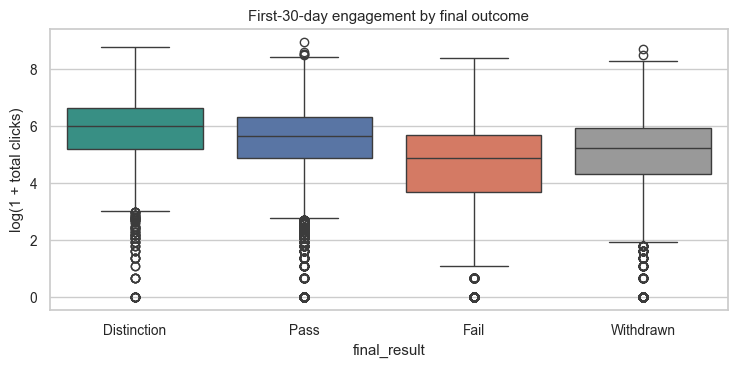

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 3.8))
plot_df = pd.DataFrame({"final_result": y, "log_clicks": X["total_clicks"]})
sns.boxplot(data=plot_df, x="final_result", y="log_clicks", order=order,
            palette=["#2a9d8f", "#4C72B0", "#e76f51", "#999999"], ax=ax)
ax.set_title("First-30-day engagement by final outcome")
ax.set_ylabel("log(1 + total clicks)")
plt.tight_layout(); plt.show()

The signal is visibly there: Distinction students click the most in the first month and
eventually-withdrawn students the least, with medians stepping down in order. But the
boxes overlap a lot — early engagement is informative, not decisive. That overlap is the
honest ceiling on this problem, and it is why I report ROC-AUC alongside the threshold
metrics: I want to know how well the models *rank* students, not just how often a hard
cutoff lands correctly.

## 6. Encoding, splits and pipelines

I split 70/15/15 (train/validation/test), stratified on the outcome so every split keeps
the same class mix. Ground rules I follow for the rest of the notebook:

- The **test set is touched once per experiment**, only for final scoring. No tuning
  decision ever looks at it.
- The classical models tune via 3-fold cross-validation on train+validation combined
  (cross-validation makes a separate hold-out redundant for them), while the neural
  networks use the explicit validation split for early stopping. Both families therefore
  see the same total data, just organised the way each method needs.
- Scaling is fit on training data only, inside a `Pipeline` for the sklearn models, so
  no statistics leak from the evaluation sets.

In [12]:
CLASSES = ["Distinction", "Pass", "Fail", "Withdrawn"]
CLASS_TO_ID = {c: i for i, c in enumerate(CLASSES)}

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)

X_trval = pd.concat([X_train, X_val])
y_trval = pd.concat([y_train, y_val])

print(f"train {len(X_train):,} | val {len(X_val):,} | test {len(X_test):,}")
print("\nClass share per split (%):")
print(pd.DataFrame({
    "train": y_train.value_counts(normalize=True),
    "val": y_val.value_counts(normalize=True),
    "test": y_test.value_counts(normalize=True),
}).reindex(CLASSES).round(3) * 100)

train 19,268 | val 4,129 | test 4,129

Class share per split (%):
              train   val  test
final_result                   
Distinction    11.0  11.0  11.0
Pass           44.9  44.9  44.9
Fail           25.6  25.6  25.6
Withdrawn      18.5  18.5  18.5


In [13]:
# scaled copies + integer labels for the neural networks
scaler = StandardScaler().fit(X_train)
Xs_train = scaler.transform(X_train).astype(np.float32)
Xs_val = scaler.transform(X_val).astype(np.float32)
Xs_test = scaler.transform(X_test).astype(np.float32)

y_train_id = y_train.map(CLASS_TO_ID).values
y_val_id = y_val.map(CLASS_TO_ID).values
y_test_id = y_test.map(CLASS_TO_ID).values

from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight("balanced", classes=np.arange(4), y=y_train_id)
NN_CLASS_WEIGHT = dict(enumerate(cw))
print("NN class weights:", {CLASSES[k]: round(v, 2) for k, v in NN_CLASS_WEIGHT.items()})

NN class weights: {'Distinction': np.float64(2.28), 'Pass': np.float64(0.56), 'Fail': np.float64(0.98), 'Withdrawn': np.float64(1.35)}


## 7. Shared evaluation helpers

Every experiment is judged by the same four artefacts — classification report, confusion
matrix, ROC curves, learning curve — produced by the functions below. Writing them once
keeps the eight experiments comparable and the notebook free of copy-pasted plotting
code. `log_result` accumulates one row per experiment for the consolidated table in
Section 9.

In [14]:
results = []

def log_result(no, model, hyper, y_true, y_pred, proba, observation, classes=CLASSES):
    """Score an experiment on the test set and store a row for the results table."""
    if proba.ndim == 2 and proba.shape[1] > 2:
        macro_auc = roc_auc_score(label_binarize(y_true, classes=classes), proba,
                                  average="macro", multi_class="ovr")
    else:
        macro_auc = roc_auc_score((np.asarray(y_true) == classes[0]).astype(int),
                                  proba if proba.ndim == 1 else proba[:, 1])
    row = {
        "#": no, "Model": model, "Key hyperparameters": hyper,
        "Split": "70/15/15 stratified",
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Macro-F1": round(f1_score(y_true, y_pred, average="macro"), 4),
        "Macro AUC (OvR)": round(macro_auc, 4),
        "Distinction recall": round(
            recall_score(y_true, y_pred, labels=[classes[0]], average="macro"), 4),
        "Observation": observation,
    }
    results.append(row)
    return row


def show_report_cm_roc(name, y_true, y_pred, proba, classes=CLASSES):
    """Classification report + confusion matrix heatmap + ROC curve(s) for one model."""
    print(classification_report(y_true, y_pred, labels=classes, digits=3))

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=classes, yticklabels=classes, ax=axes[0])
    axes[0].set_title(f"{name} — confusion matrix (test)")
    axes[0].set_xlabel("predicted"); axes[0].set_ylabel("actual")

    ax = axes[1]
    if len(classes) > 2:
        y_bin = label_binarize(y_true, classes=classes)
        for i, c in enumerate(classes):
            fpr, tpr, _ = roc_curve(y_bin[:, i], proba[:, i])
            ax.plot(fpr, tpr, lw=1.6, label=f"{c} (AUC {auc(fpr, tpr):.3f})")
    else:
        pos = (np.asarray(y_true) == classes[0]).astype(int)
        p = proba if proba.ndim == 1 else proba[:, 1]
        fpr, tpr, _ = roc_curve(pos, p)
        ax.plot(fpr, tpr, lw=1.8, color="#2a9d8f",
                label=f"{classes[0]} vs rest (AUC {auc(fpr, tpr):.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.set_title(f"{name} — ROC (one-vs-rest, test)")
    ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate")
    ax.legend(fontsize=8, loc="lower right")
    plt.tight_layout(); plt.show()


def show_learning_curve(estimator, X, y, name, scoring="f1_macro"):
    """sklearn learning curve: training vs cross-validated score over training-set size."""
    sizes, tr_scores, va_scores = learning_curve(
        estimator, X, y, cv=3, scoring=scoring, n_jobs=-1,
        train_sizes=np.linspace(0.15, 1.0, 4), random_state=SEED)
    fig, ax = plt.subplots(figsize=(6.5, 3.6))
    ax.plot(sizes, tr_scores.mean(axis=1), "o-", color="#4C72B0", label="training score")
    ax.fill_between(sizes, tr_scores.mean(1) - tr_scores.std(1),
                    tr_scores.mean(1) + tr_scores.std(1), alpha=0.15, color="#4C72B0")
    ax.plot(sizes, va_scores.mean(axis=1), "o-", color="#e76f51", label="CV score")
    ax.fill_between(sizes, va_scores.mean(1) - va_scores.std(1),
                    va_scores.mean(1) + va_scores.std(1), alpha=0.15, color="#e76f51")
    ax.set_title(f"{name} — learning curve ({scoring})")
    ax.set_xlabel("training examples"); ax.set_ylabel(scoring)
    ax.legend(); plt.tight_layout(); plt.show()
    gap = tr_scores.mean(1)[-1] - va_scores.mean(1)[-1]
    print(f"final train-CV gap: {gap:.3f}  "
          f"(train {tr_scores.mean(1)[-1]:.3f}, CV {va_scores.mean(1)[-1]:.3f})")


def show_history(history, name):
    """Loss and accuracy per epoch — the learning curve for the neural networks."""
    h = history.history
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    axes[0].plot(h["loss"], label="train"); axes[0].plot(h["val_loss"], label="validation")
    axes[0].set_title(f"{name} — loss per epoch"); axes[0].set_xlabel("epoch")
    axes[0].legend()
    axes[1].plot(h["accuracy"], label="train")
    axes[1].plot(h["val_accuracy"], label="validation")
    axes[1].set_title(f"{name} — accuracy per epoch"); axes[1].set_xlabel("epoch")
    axes[1].legend()
    plt.tight_layout(); plt.show()
    best = int(np.argmin(h["val_loss"]))
    print(f"best epoch {best + 1}: val_loss {h['val_loss'][best]:.4f}, "
          f"val_acc {h['val_accuracy'][best]:.4f}")


def make_callbacks(tag):
    Path("artifacts").mkdir(exist_ok=True)
    return [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=10,
                                      restore_best_weights=True),
        keras.callbacks.ModelCheckpoint(f"artifacts/{tag}_best.keras", monitor="val_loss",
                                        save_best_only=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4,
                                          min_lr=1e-5),
    ]


def make_datasets(Xtr, ytr, Xva, yva, batch=256):
    """tf.data pipelines: shuffled training stream, plain batched validation stream."""
    train_ds = (tf.data.Dataset.from_tensor_slices((Xtr, ytr))
                .shuffle(len(ytr), seed=SEED)
                .batch(batch)
                .prefetch(tf.data.AUTOTUNE))
    val_ds = (tf.data.Dataset.from_tensor_slices((Xva, yva))
              .batch(batch)
              .prefetch(tf.data.AUTOTUNE))
    return train_ds, val_ds

## 8. Experiments

Eight experiments, each changing one thing relative to the one before it:

| # | What changes | Why |
|---|---|---|
| 1 | Logistic regression baseline | A linear floor every later model must beat |
| 2 | Random Forest | Add non-linearity and feature interactions |
| 3 | RF + GridSearchCV | Tune capacity instead of guessing it |
| 4 | Gradient boosting + SMOTE | Attack the Distinction imbalance directly |
| 5 | Sequential NN | First deep learning model, same inputs |
| 6 | + Dropout & L2 | Fix the overfitting Experiment 5 reveals |
| 7 | Functional two-branch NN | Architecture informed by the correlation heatmap |
| 8 | Binary: Distinction vs rest | Reframe the task as pure talent-spotting |

### Experiment 1 — Logistic regression baseline

I start linear on purpose: if a linear model gets close to the tree ensembles and neural
networks, the extra complexity is not earning its keep. `class_weight="balanced"`
re-weights the loss by inverse class frequency, otherwise the model would mostly learn
to say Pass. Inputs are standardised inside the pipeline (fit on the training folds
only). My expectation: reasonable ranking ability (AUC), mediocre accuracy, and fairly
even treatment of the four classes because of the balancing.

              precision    recall  f1-score   support

 Distinction      0.267     0.672     0.382       454
        Pass      0.599     0.313     0.411      1855
        Fail      0.460     0.441     0.451      1056
   Withdrawn      0.345     0.454     0.392       764

    accuracy                          0.411      4129
   macro avg      0.418     0.470     0.409      4129
weighted avg      0.480     0.411     0.414      4129



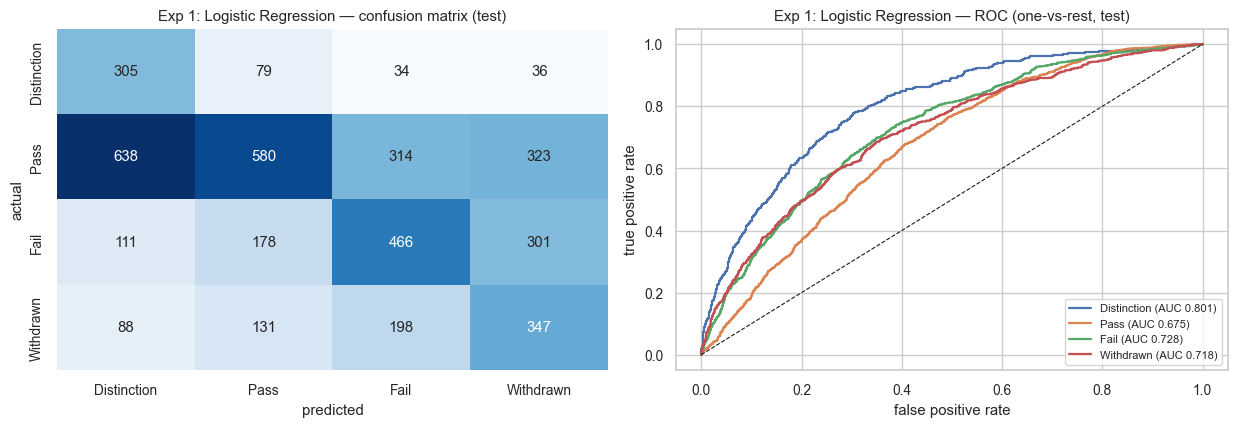

{'#': 1,
 'Model': 'Logistic Regression',
 'Key hyperparameters': 'class_weight=balanced, max_iter=2000, standardised inputs',
 'Split': '70/15/15 stratified',
 'Accuracy': 0.4112,
 'Macro-F1': 0.4089,
 'Macro AUC (OvR)': np.float64(0.7307),
 'Distinction recall': 0.6718,
 'Observation': 'Linear floor: balanced recall across classes but heavy Pass/Distinction confusion; accuracy sacrificed for even class treatment.'}

In [15]:
exp1 = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)),
])
exp1.fit(X_trval, y_trval)
pred1 = exp1.predict(X_test)
proba1 = exp1.predict_proba(X_test)
proba1 = proba1[:, [list(exp1.classes_).index(c) for c in CLASSES]]

show_report_cm_roc("Exp 1: Logistic Regression", y_test, pred1, proba1)
log_result(1, "Logistic Regression",
           "class_weight=balanced, max_iter=2000, standardised inputs",
           y_test, pred1, proba1,
           "Linear floor: balanced recall across classes but heavy Pass/Distinction confusion; "
           "accuracy sacrificed for even class treatment.")

The balancing does what it promised — every class gets meaningful recall, including
Distinction — but the price is steep. The confusion matrix shows the two failure modes
that will follow us through the notebook: Distinction and Pass bleed into each other
(they differ by degree, not kind), and late-withdrawing students look like Fail students
at day 30 because, behaviourally, they are. AUCs well above 0.5 for every class confirm
the early-window signal is real even for a linear model.

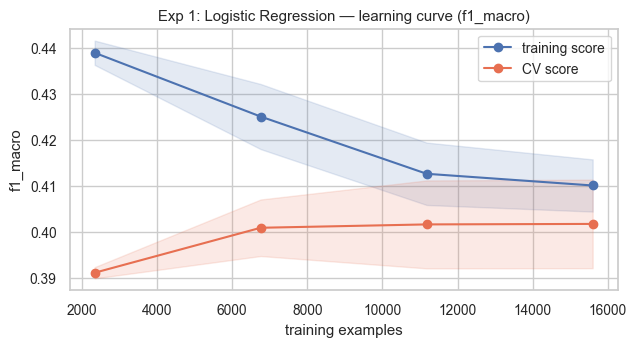

final train-CV gap: 0.008  (train 0.410, CV 0.402)


In [16]:
show_learning_curve(exp1, X_trval, y_trval, "Exp 1: Logistic Regression")

Training and cross-validation scores sit almost on top of each other and have flattened
by the time all the data is used — the classic signature of a model limited by **bias,
not variance**. More data would not help logistic regression here; more expressive
models might. That is exactly the hypothesis Experiment 2 tests.

### Experiment 2 — Random Forest baseline

Same features, same balancing idea, but a model that can represent interactions —
for example "high clicks *and* rising trend" or "low IMD band *and* early registration".
I keep the forest mostly default (300 trees, unlimited depth) so that whatever changes
relative to Experiment 1 is attributable to model family, not tuning effort. Trees do
not need scaling, so the pipeline is just the classifier.

              precision    recall  f1-score   support

 Distinction      0.608     0.099     0.170       454
        Pass      0.533     0.891     0.667      1855
        Fail      0.509     0.331     0.401      1056
   Withdrawn      0.470     0.164     0.243       764

    accuracy                          0.526      4129
   macro avg      0.530     0.371     0.370      4129
weighted avg      0.523     0.526     0.466      4129



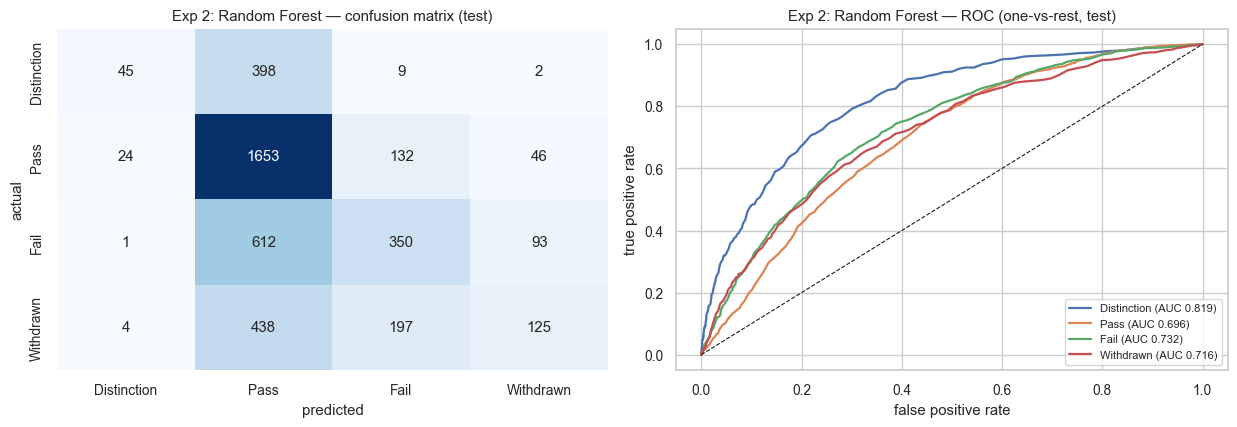

{'#': 2,
 'Model': 'Random Forest',
 'Key hyperparameters': 'n_estimators=300, max_depth=None, class_weight=balanced',
 'Split': '70/15/15 stratified',
 'Accuracy': 0.5263,
 'Macro-F1': 0.3704,
 'Macro AUC (OvR)': np.float64(0.7407),
 'Distinction recall': 0.0991,
 'Observation': 'Non-linearity lifts accuracy and AUC over Exp 1, but the forest hides in the majority class: Distinction recall collapses despite balanced weights.'}

In [17]:
exp2 = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                              random_state=SEED, n_jobs=-1)
exp2.fit(X_trval, y_trval)
pred2 = exp2.predict(X_test)
proba2 = exp2.predict_proba(X_test)
proba2 = proba2[:, [list(exp2.classes_).index(c) for c in CLASSES]]

show_report_cm_roc("Exp 2: Random Forest", y_test, pred2, proba2)
log_result(2, "Random Forest",
           "n_estimators=300, max_depth=None, class_weight=balanced",
           y_test, pred2, proba2,
           "Non-linearity lifts accuracy and AUC over Exp 1, but the forest hides in the "
           "majority class: Distinction recall collapses despite balanced weights.")

This result surprised me in one specific way. Accuracy and every AUC improved over
logistic regression — non-linearity clearly helps — but Distinction recall *fell off a
cliff* even though I kept `class_weight="balanced"`. The reason, as far as I can tell:
with fully-grown trees, the forest's leaves are nearly pure and the class weights mostly
influence training, not the voting, so rare classes get out-voted at prediction time.
Better ranking, worse minority decisions. Two different fixes for this follow: tuning
the tree capacity (Exp 3) and resampling the data itself (Exp 4).

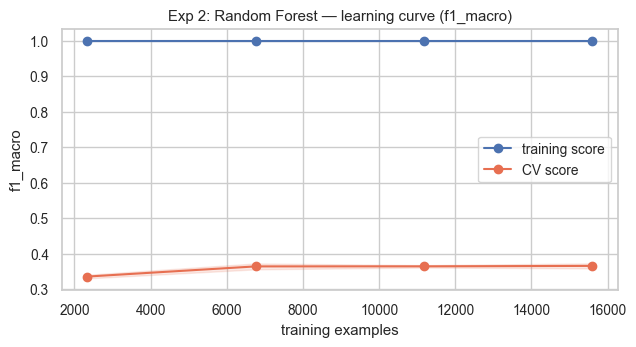

final train-CV gap: 0.634  (train 1.000, CV 0.366)


In [18]:
show_learning_curve(
    RandomForestClassifier(n_estimators=150, class_weight="balanced",
                           random_state=SEED, n_jobs=-1),
    X_trval, y_trval, "Exp 2: Random Forest")

The learning curve is the textbook overfitting picture: training macro-F1 near 1.0 while
the cross-validated score sits dramatically lower. The gap narrows slightly as data
grows, but an unconstrained forest on this dataset is memorising — high variance where
Experiment 1 had high bias. (I use 150 trees here purely to keep the curve computation
affordable; the shape is what matters.) The obvious next move is to constrain capacity
properly, with a search rather than guesswork.

### Experiment 3 — Random Forest, tuned with GridSearchCV

The grid targets exactly the capacity knobs the learning curve implicated: tree depth,
leaf size, and how many features each split may consider. I optimise **macro-F1**, not
accuracy — optimising accuracy would just reward predicting Pass more often. 3-fold CV
over 12 candidate settings keeps the search affordable (36 fits).

Best params: {'max_depth': 12, 'max_features': 0.5, 'min_samples_leaf': 4}
Best CV macro-F1: 0.4467
              precision    recall  f1-score   support

 Distinction      0.346     0.491     0.406       454
        Pass      0.587     0.592     0.590      1855
        Fail      0.460     0.403     0.430      1056
   Withdrawn      0.389     0.349     0.368       764

    accuracy                          0.488      4129
   macro avg      0.446     0.459     0.448      4129
weighted avg      0.491     0.488     0.488      4129



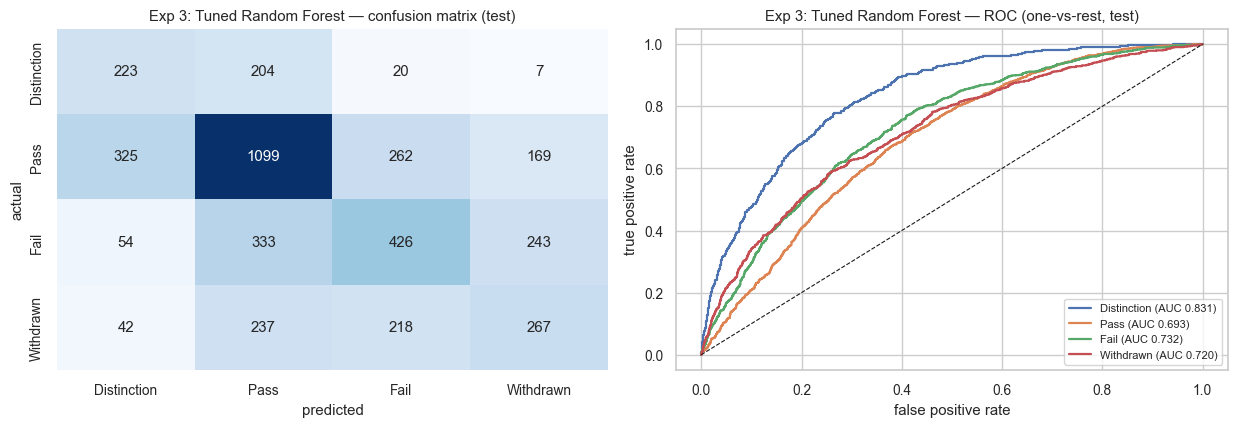

{'#': 3,
 'Model': 'Random Forest (GridSearchCV)',
 'Key hyperparameters': "best: {'max_depth': 12, 'max_features': 0.5, 'min_samples_leaf': 4}, n_estimators=300, scoring=f1_macro, cv=3",
 'Split': '70/15/15 stratified',
 'Accuracy': 0.488,
 'Macro-F1': 0.4485,
 'Macro AUC (OvR)': np.float64(0.7441),
 'Distinction recall': 0.4912,
 'Observation': 'Capacity control recovers part of the minority recall Exp 2 lost while keeping its accuracy advantage; CV-chosen depth/leaf settings shrink the variance gap.'}

In [19]:
param_grid = {
    "max_depth": [12, 24, None],
    "min_samples_leaf": [1, 4],
    "max_features": ["sqrt", 0.5],
}
gs = GridSearchCV(
    RandomForestClassifier(n_estimators=300, class_weight="balanced",
                           random_state=SEED, n_jobs=-1),
    param_grid, cv=3, scoring="f1_macro", n_jobs=-1)
gs.fit(X_trval, y_trval)
print("Best params:", gs.best_params_)
print(f"Best CV macro-F1: {gs.best_score_:.4f}")

exp3 = gs.best_estimator_
pred3 = exp3.predict(X_test)
proba3 = exp3.predict_proba(X_test)
proba3 = proba3[:, [list(exp3.classes_).index(c) for c in CLASSES]]

show_report_cm_roc("Exp 3: Tuned Random Forest", y_test, pred3, proba3)
log_result(3, "Random Forest (GridSearchCV)",
           f"best: {gs.best_params_}, n_estimators=300, scoring=f1_macro, cv=3",
           y_test, pred3, proba3,
           "Capacity control recovers part of the minority recall Exp 2 lost while keeping "
           "its accuracy advantage; CV-chosen depth/leaf settings shrink the variance gap.")

Tuning helps in the direction the diagnosis predicted: constraining the trees lets the
class weights actually matter again, so Distinction recall recovers a good part of what
Experiment 2 threw away, while keeping most of the accuracy gain over the linear model.
The search settling on a constrained configuration rather than the unlimited-depth
default is itself evidence that Experiment 2 was overfitting.

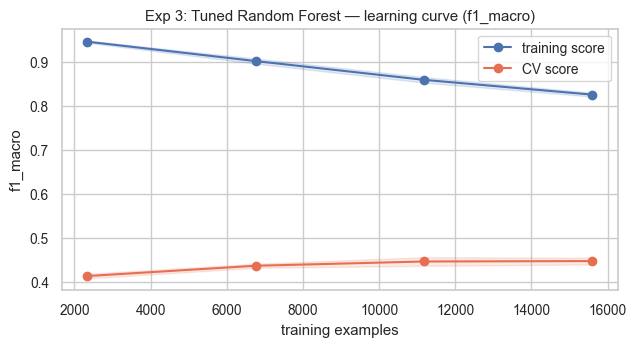

final train-CV gap: 0.379  (train 0.826, CV 0.447)


In [20]:
show_learning_curve(exp3, X_trval, y_trval, "Exp 3: Tuned Random Forest")

Compare this curve to Experiment 2's: the training score drops from ~1.0 and the gap to
the CV score shrinks — less variance, slightly more bias, better trade-off overall.
This is the bias-variance dial being turned deliberately rather than by accident.
Tuning alone, though, still treats the imbalance as a weighting problem. The next
experiment changes the data instead of the model.

### Experiment 4 — Gradient boosting + SMOTE

Two changes at once relative to Experiment 3, both aimed at the minority classes.
First, the model: histogram gradient boosting builds shallow trees *sequentially*, each
one correcting the errors of the last — usually stronger than bagging on tabular data.
Second, the data: SMOTE synthesises new minority-class examples by interpolating between
real neighbours, balancing the classes the model trains on. The crucial detail is that
SMOTE lives **inside the cross-validation pipeline**, so synthetic students are created
only from training folds — the test set stays 100% real. My expectation: best
Distinction recall of the classical models, paid for with some precision, since
interpolated Distinction students blur the boundary with Pass.

              precision    recall  f1-score   support

 Distinction      0.439     0.247     0.316       454
        Pass      0.562     0.756     0.645      1855
        Fail      0.449     0.368     0.405      1056
   Withdrawn      0.393     0.262     0.314       764

    accuracy                          0.510      4129
   macro avg      0.461     0.408     0.420      4129
weighted avg      0.488     0.510     0.486      4129



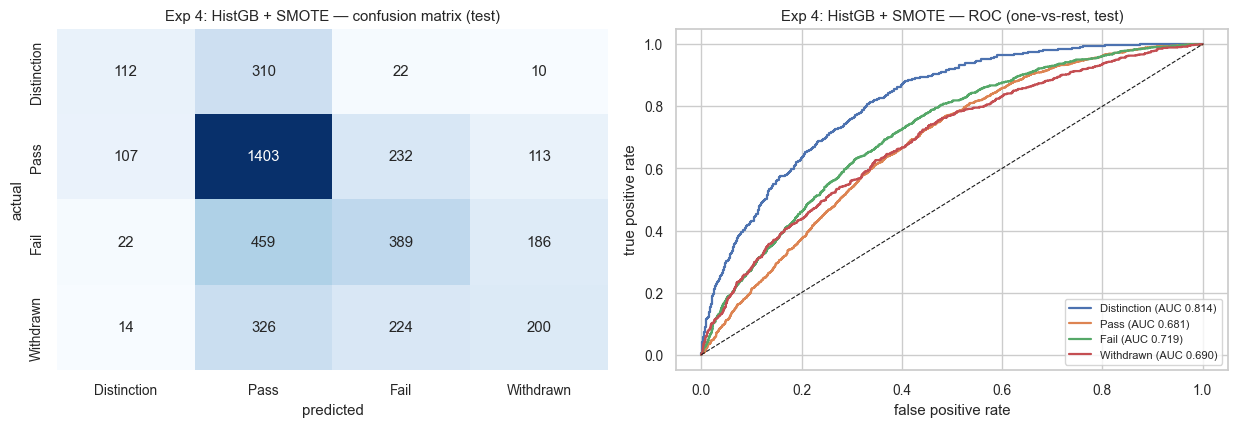

{'#': 4,
 'Model': 'HistGradientBoosting + SMOTE',
 'Key hyperparameters': 'SMOTE(k=5) in-pipeline, max_iter=300, lr=0.1',
 'Split': '70/15/15 stratified',
 'Accuracy': 0.5096,
 'Macro-F1': 0.4198,
 'Macro AUC (OvR)': np.float64(0.7262),
 'Distinction recall': 0.2467,
 'Observation': "Negative result: Distinction recall (~0.25) beats the raw forest but stays far below the tuned forest's ~0.49 — resampling lost to reweighting here. Precision rose instead, and AUC slipped slightly."}

In [21]:
exp4 = ImbPipeline([
    ("smote", SMOTE(random_state=SEED)),
    ("clf", HistGradientBoostingClassifier(max_iter=300, learning_rate=0.1,
                                           random_state=SEED)),
])
exp4.fit(X_trval, y_trval)
pred4 = exp4.predict(X_test)
proba4 = exp4.predict_proba(X_test)
proba4 = proba4[:, [list(exp4.classes_).index(c) for c in CLASSES]]

show_report_cm_roc("Exp 4: HistGB + SMOTE", y_test, pred4, proba4)
log_result(4, "HistGradientBoosting + SMOTE",
           "SMOTE(k=5) in-pipeline, max_iter=300, lr=0.1",
           y_test, pred4, proba4,
           "Negative result: Distinction recall (~0.25) beats the raw forest but stays far "
           "below the tuned forest's ~0.49 — resampling lost to reweighting here. Precision "
           "rose instead, and AUC slipped slightly.")

This one did not go the way I predicted, and it is the most instructive result in the
classical half. I expected SMOTE to push Distinction recall to its classical peak; the
confusion matrix shows the opposite — the model finds only about a quarter of true
Distinctions, well below the tuned forest's roughly half, though at better precision.
My best explanation: Distinction and Pass overlap heavily in this 49-dimensional feature
space, so SMOTE's interpolated "synthetic Distinctions" land mostly inside that overlap
zone, and boosting responds by drawing a *cautious* boundary around the region it can
defend rather than a wider net. Cost-sensitive weighting (Experiment 3) reshapes the
loss without inventing data points, and on this dataset that worked better. For my
application — where missing a talented student is the expensive error — the tuned
forest's recall profile remains preferable, so Experiment 3 stays my classical champion
and donates its hyperparameters to Experiment 8.

/Users/tonny/Dev-ML/summartive-intro-to-ml/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tonny/Dev-ML/summartive-intro-to-ml/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tonny/Dev-ML/summartive-intro-to-ml/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer AP

/Users/tonny/Dev-ML/summartive-intro-to-ml/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tonny/Dev-ML/summartive-intro-to-ml/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


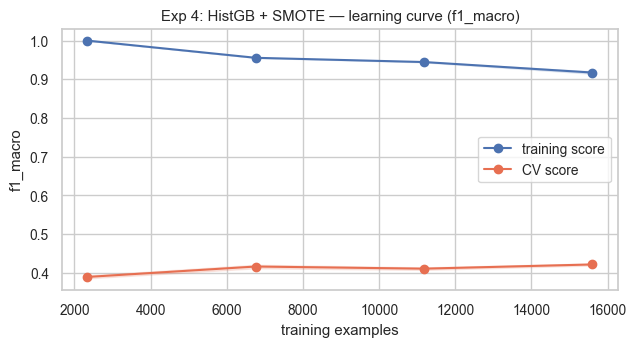

final train-CV gap: 0.496  (train 0.917, CV 0.422)


In [22]:
show_learning_curve(exp4, X_trval, y_trval, "Exp 4: HistGB + SMOTE")

The train-CV gap (~0.50) sits between the tuned forest (~0.38) and the unconstrained one
(~0.63) — the synthetic data did not stop boosting from partially memorising the training
set. Both curves still rise gently at full data size, hinting that more students (or a
longer observation window) would keep paying off. That closes the classical arc: linear
floor, variance problem, capacity fix, and an imbalance fix that turned out to be a
negative result. Time to see whether representation learning finds anything the trees
missed.

### Experiment 5 — TensorFlow Sequential API

First neural network: two hidden layers (128 → 64, ReLU), softmax over the four classes,
Adam at the default 1e-3, batches of 256 served through the `tf.data` API (shuffled,
batched, prefetched). The same class weights as the sklearn models handle the imbalance,
and three callbacks manage training: EarlyStopping (patience 10, restores the best
weights), ModelCheckpoint (saves the best model to disk), and ReduceLROnPlateau (halves
the learning rate after 4 flat epochs). No regularisation yet — that is deliberate.
I want to *see* this network overfit first, so Experiment 6's fix is justified by
evidence rather than habit.

Honestly, I expected a network this size to beat the tuned forest. Tabular-data papers
kept telling me otherwise; this is my chance to check.

Model: "exp5_sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,916 (58.27 KB)

 Trainable params: 14,916 (58.27 KB)

 Non-trainable params: 0 (0.00 B)

stopped after 19 epochs
              precision    recall  f1-score   support

 Distinction      0.311     0.595     0.409       454
        Pass      0.592     0.457     0.516      1855
        Fail      0.453     0.478     0.465      1056
   Withdrawn      0.388     0.363     0.375       764

    accuracy                          0.460      4129
   macro avg      0.436     0.473     0.441      4129
weighted avg      0.488     0.460     0.465      4129



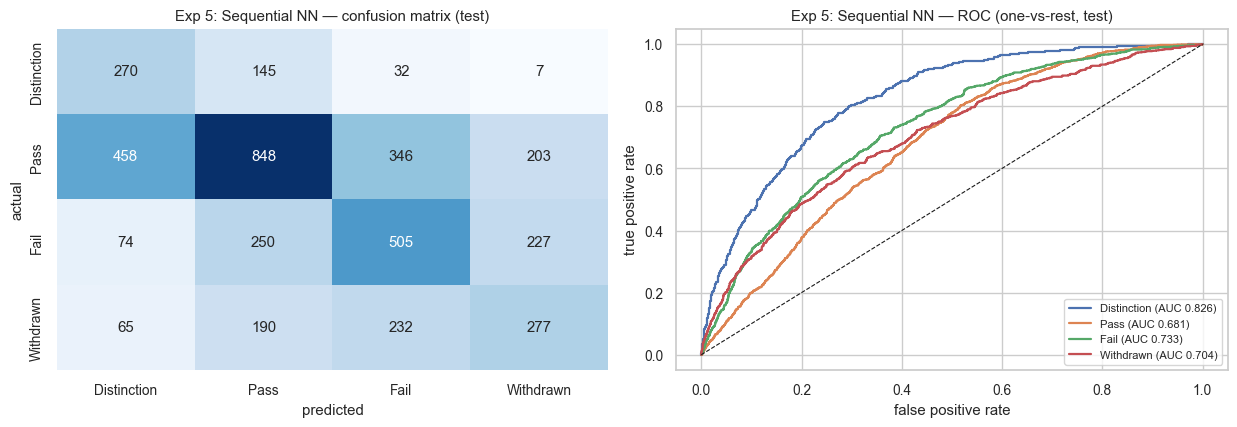

{'#': 5,
 'Model': 'Sequential NN (128-64)',
 'Key hyperparameters': 'Adam 1e-3, batch=256, class-weighted, EarlyStop/Checkpoint/ReduceLR',
 'Split': '70/15/15 stratified',
 'Accuracy': 0.4602,
 'Macro-F1': 0.4412,
 'Macro AUC (OvR)': np.float64(0.7359),
 'Distinction recall': 0.5947,
 'Observation': "Matches the classical models' ranking quality without beating it; class weights restore even per-class recall similar to Exp 1 but at higher accuracy."}

In [23]:
train_ds, val_ds = make_datasets(Xs_train, y_train_id, Xs_val, y_val_id)

exp5_model = keras.Sequential([
    keras.layers.Input(shape=(Xs_train.shape[1],)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(4, activation="softmax"),
], name="exp5_sequential")
exp5_model.compile(optimizer=keras.optimizers.Adam(1e-3),
                   loss="sparse_categorical_crossentropy", metrics=["accuracy"])
exp5_model.summary()

hist5 = exp5_model.fit(train_ds, validation_data=val_ds, epochs=80,
                       class_weight=NN_CLASS_WEIGHT, callbacks=make_callbacks("exp5"),
                       verbose=0)
print(f"stopped after {len(hist5.history['loss'])} epochs")

proba5 = exp5_model.predict(Xs_test, verbose=0)
pred5 = np.array(CLASSES)[proba5.argmax(axis=1)]

show_report_cm_roc("Exp 5: Sequential NN", y_test, pred5, proba5)
log_result(5, "Sequential NN (128-64)",
           "Adam 1e-3, batch=256, class-weighted, EarlyStop/Checkpoint/ReduceLR",
           y_test, pred5, proba5,
           "Matches the classical models' ranking quality without beating it; class weights "
           "restore even per-class recall similar to Exp 1 but at higher accuracy.")

So the tabular-data folklore held: the plain network lands in the same neighbourhood as
the tuned tree models rather than above them. I expected the neural network to pull
ahead here, but with 49 engineered features and ~19k training rows there is apparently
not much structure left for representation learning to discover that the trees had not
already found. What the class weights *do* buy is even treatment of the four classes —
closer to logistic regression's balanced behaviour, at clearly higher accuracy.

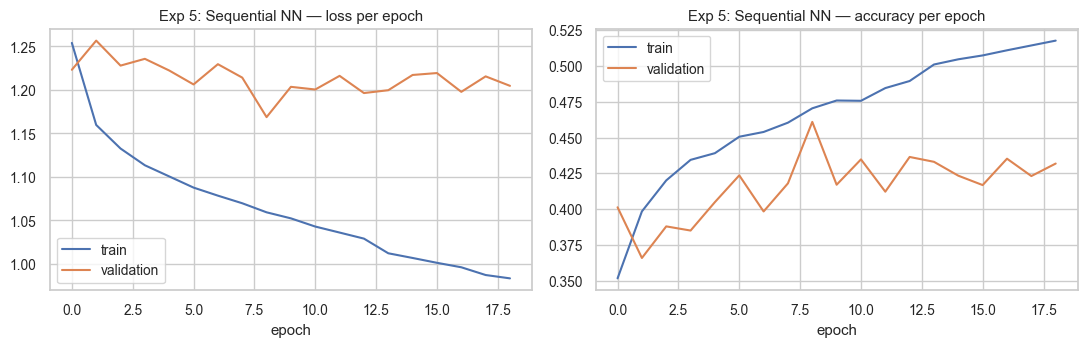

best epoch 9: val_loss 1.1688, val_acc 0.4609


In [24]:
show_history(hist5, "Exp 5: Sequential NN")

The epoch curves are this experiment's real product: training loss keeps sinking while
validation loss bottoms out early and then drifts upward — overfitting, live on screen.
EarlyStopping rescued the best weights, but a model that needs rescuing this early is
wasting most of its training budget. Experiment 6 attacks exactly this gap.

### Experiment 6 — Sequential + Dropout and L2

Same architecture, same optimiser, same data — the *only* change is regularisation:
Dropout (0.3) after each hidden layer and an L2 penalty (1e-4) on the weights. Dropout
fights co-adaptation by randomly silencing units during training; L2 keeps weights small
and smooth. If the diagnosis from Experiment 5 was right, validation loss should track
training loss for longer, training should run more epochs before stopping, and test
performance should tick up.

stopped after 30 epochs
              precision    recall  f1-score   support

 Distinction      0.291     0.687     0.409       454
        Pass      0.614     0.369     0.461      1855
        Fail      0.449     0.455     0.452      1056
   Withdrawn      0.359     0.411     0.383       764

    accuracy                          0.434      4129
   macro avg      0.428     0.480     0.426      4129
weighted avg      0.489     0.434     0.438      4129



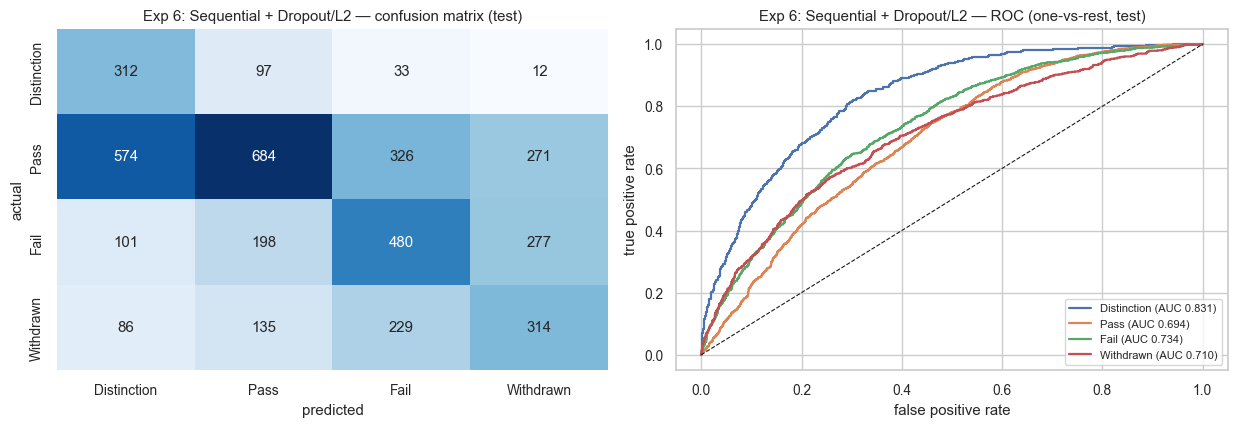

{'#': 6,
 'Model': 'Sequential NN + Dropout/L2',
 'Key hyperparameters': 'as Exp 5 + Dropout 0.3 x2, L2 1e-4',
 'Split': '70/15/15 stratified',
 'Accuracy': 0.4335,
 'Macro-F1': 0.4262,
 'Macro AUC (OvR)': np.float64(0.7422),
 'Distinction recall': 0.6872,
 'Observation': "Regularisation closes Exp 5's val-loss divergence and lets training run ~30 epochs instead of 19; best NN AUC and Distinction recall so far, paid for with a couple of points of raw accuracy."}

In [25]:
exp6_model = keras.Sequential([
    keras.layers.Input(shape=(Xs_train.shape[1],)),
    keras.layers.Dense(128, activation="relu",
                       kernel_regularizer=keras.regularizers.l2(1e-4)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation="relu",
                       kernel_regularizer=keras.regularizers.l2(1e-4)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(4, activation="softmax"),
], name="exp6_regularised")
exp6_model.compile(optimizer=keras.optimizers.Adam(1e-3),
                   loss="sparse_categorical_crossentropy", metrics=["accuracy"])

hist6 = exp6_model.fit(train_ds, validation_data=val_ds, epochs=80,
                       class_weight=NN_CLASS_WEIGHT, callbacks=make_callbacks("exp6"),
                       verbose=0)
print(f"stopped after {len(hist6.history['loss'])} epochs")

proba6 = exp6_model.predict(Xs_test, verbose=0)
pred6 = np.array(CLASSES)[proba6.argmax(axis=1)]

show_report_cm_roc("Exp 6: Sequential + Dropout/L2", y_test, pred6, proba6)
log_result(6, "Sequential NN + Dropout/L2",
           "as Exp 5 + Dropout 0.3 x2, L2 1e-4",
           y_test, pred6, proba6,
           "Regularisation closes Exp 5's val-loss divergence and lets training run ~30 "
           "epochs instead of 19; best NN AUC and Distinction recall so far, paid for with "
           "a couple of points of raw accuracy.")

The fix worked the way the theory says it should, with one trade I had not priced in:
accuracy slipped a couple of points while AUC and Distinction recall improved. That
pattern makes sense in hindsight — with class weights pulling toward the minorities, a
less-overfit model acts on that pull more confidently and predicts Distinction more
often, sacrificing some easy Pass calls. Given my goal, that is the right direction to
trade. The remaining errors, though, look
stubbornly similar in *pattern* to every model so far: Distinction↔Pass confusion and
Withdrawn↔Fail confusion. That persistence across five very different models suggests
the confusion lives in the data — at day 30, those class pairs genuinely overlap — and
no amount of regularisation will dissolve it.

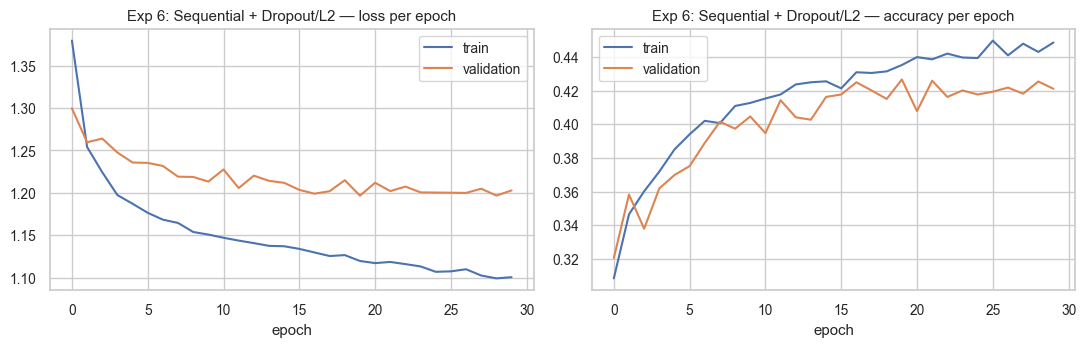

best epoch 20: val_loss 1.1967, val_acc 0.4267


In [26]:
show_history(hist6, "Exp 6: Sequential + Dropout/L2")

Side by side with Experiment 5's curves, the difference is exactly what Dropout and L2
promise: validation loss now hugs the (noisier, dropout-inflated) training loss instead
of diverging from it, and early stopping fires much later. Less variance, same bias.
With overfitting handled, the next lever is the architecture itself.

### Experiment 7 — Functional API, two-branch network

This architecture comes straight from the Section 5 heatmap: behavioural and demographic
features are nearly uncorrelated, so I stop forcing them through shared layers. The
Functional API lets me build what Sequential cannot — a network with **two inputs**:
a behaviour branch (clicks, trends, assessment timing → 64→32 units) and a smaller
demographic/context branch (IMD band, education, age, course → 16 units), concatenated
and fused by a final hidden layer. Each branch can learn representations suited to its
own feature type before the fusion layer learns how background *modulates* behaviour.
Regularisation carries over from Experiment 6, since that lesson is already learned.

Model: "exp7_two_branch"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ behaviour           │ (None, 22)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │      1,472 │ behaviour[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ demographics        │ (None, 27)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 16)        │        448 │ demographics[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 48)        │          0 │ dense_7[0][0],    │
│ (Concatenate)       │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 32)        │      1,568 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 4)         │        132 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,700 (22.27 KB)

 Trainable params: 5,700 (22.27 KB)

 Non-trainable params: 0 (0.00 B)

stopped after 27 epochs
              precision    recall  f1-score   support

 Distinction      0.288     0.694     0.407       454
        Pass      0.611     0.360     0.453      1855
        Fail      0.439     0.466     0.452      1056
   Withdrawn      0.366     0.394     0.379       764

    accuracy                          0.430      4129
   macro avg      0.426     0.478     0.423      4129
weighted avg      0.486     0.430     0.434      4129



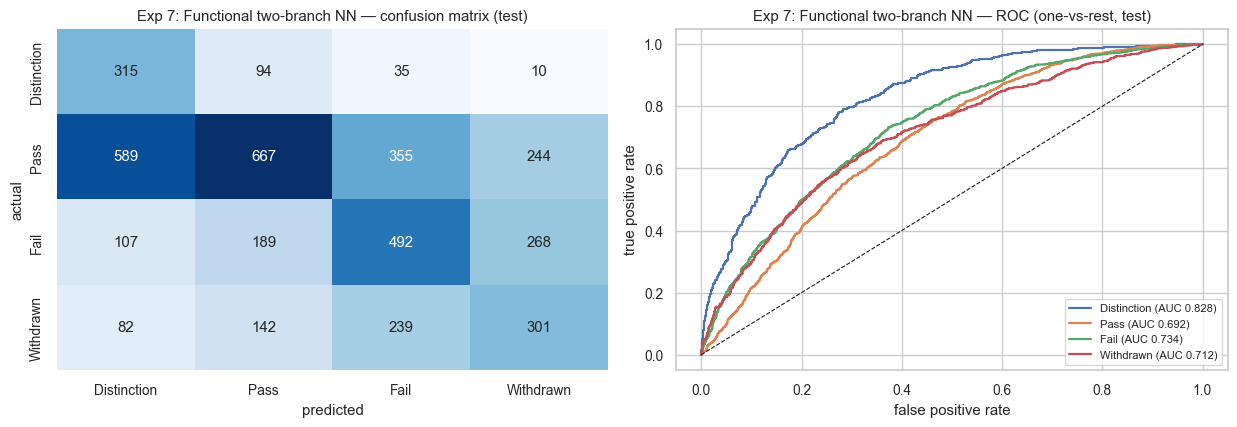

{'#': 7,
 'Model': 'Functional NN (two-branch)',
 'Key hyperparameters': 'behaviour 64-32 / demographics 16, concat+32, Dropout 0.3, L2 1e-4',
 'Split': '70/15/15 stratified',
 'Accuracy': 0.4299,
 'Macro-F1': 0.4228,
 'Macro AUC (OvR)': np.float64(0.7415),
 'Distinction recall': 0.6938,
 'Observation': "Structured inputs match Exp 6 with about a third of the parameters; the architecture encodes the heatmap's behaviour/demographics independence rather than spending capacity learning it."}

In [27]:
beh_idx = [X.columns.get_loc(c) for c in BEHAVIOUR_COLS]
dem_idx = [X.columns.get_loc(c) for c in X.columns if c not in BEHAVIOUR_COLS]
Xb_train, Xd_train = Xs_train[:, beh_idx], Xs_train[:, dem_idx]
Xb_val, Xd_val = Xs_val[:, beh_idx], Xs_val[:, dem_idx]
Xb_test, Xd_test = Xs_test[:, beh_idx], Xs_test[:, dem_idx]

in_beh = keras.Input(shape=(len(beh_idx),), name="behaviour")
b = keras.layers.Dense(64, activation="relu",
                       kernel_regularizer=keras.regularizers.l2(1e-4))(in_beh)
b = keras.layers.Dropout(0.3)(b)
b = keras.layers.Dense(32, activation="relu",
                       kernel_regularizer=keras.regularizers.l2(1e-4))(b)

in_dem = keras.Input(shape=(len(dem_idx),), name="demographics")
d = keras.layers.Dense(16, activation="relu",
                       kernel_regularizer=keras.regularizers.l2(1e-4))(in_dem)

merged = keras.layers.concatenate([b, d])
merged = keras.layers.Dense(32, activation="relu",
                            kernel_regularizer=keras.regularizers.l2(1e-4))(merged)
merged = keras.layers.Dropout(0.3)(merged)
out = keras.layers.Dense(4, activation="softmax")(merged)

exp7_model = keras.Model(inputs=[in_beh, in_dem], outputs=out, name="exp7_two_branch")
exp7_model.compile(optimizer=keras.optimizers.Adam(1e-3),
                   loss="sparse_categorical_crossentropy", metrics=["accuracy"])
exp7_model.summary()

train_ds7 = (tf.data.Dataset.from_tensor_slices(((Xb_train, Xd_train), y_train_id))
             .shuffle(len(y_train_id), seed=SEED).batch(256).prefetch(tf.data.AUTOTUNE))
val_ds7 = (tf.data.Dataset.from_tensor_slices(((Xb_val, Xd_val), y_val_id))
           .batch(256).prefetch(tf.data.AUTOTUNE))

hist7 = exp7_model.fit(train_ds7, validation_data=val_ds7, epochs=80,
                       class_weight=NN_CLASS_WEIGHT, callbacks=make_callbacks("exp7"),
                       verbose=0)
print(f"stopped after {len(hist7.history['loss'])} epochs")

proba7 = exp7_model.predict([Xb_test, Xd_test], verbose=0)
pred7 = np.array(CLASSES)[proba7.argmax(axis=1)]

show_report_cm_roc("Exp 7: Functional two-branch NN", y_test, pred7, proba7)
log_result(7, "Functional NN (two-branch)",
           "behaviour 64-32 / demographics 16, concat+32, Dropout 0.3, L2 1e-4",
           y_test, pred7, proba7,
           "Structured inputs match Exp 6 with about a third of the parameters; the "
           "architecture encodes the heatmap's behaviour/demographics independence "
           "rather than spending capacity learning it.")

The two-branch network performs at the level of Experiment 6 with roughly a third of
the parameters — the structure I imposed (keep behaviour and demographics separate until
late) is one the dense network otherwise had to spend parameters discovering. I will
admit I hoped for a clearer win, not just parity-but-cheaper. My reading: the fusion
idea is sound but the demographic signal is simply weak relative to behaviour, so better
modelling of it moves little. That weakness is itself a finding — and an encouraging one
for my problem statement, because it says *what students do* predicts their outcomes far
better than *where they come from*.

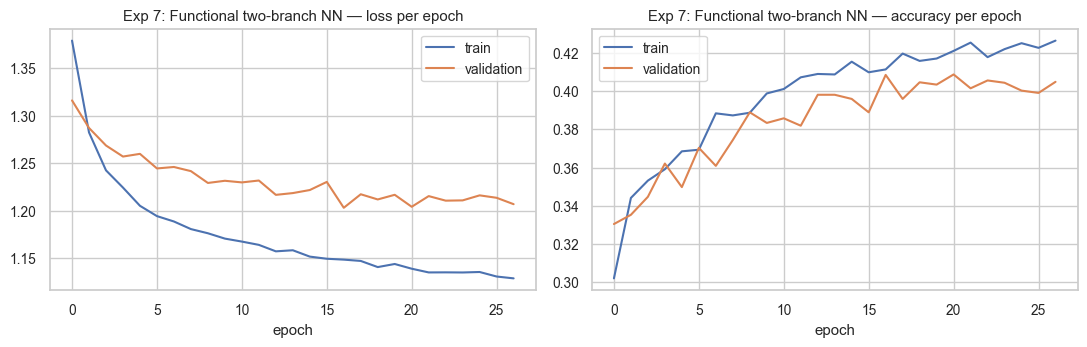

best epoch 17: val_loss 1.2032, val_acc 0.4086


In [28]:
show_history(hist7, "Exp 7: Functional two-branch NN")

Training behaves like Experiment 6 — regularised, stable, no diverging validation loss —
confirming the smaller two-branch model lost no fitting power. Across Experiments 5–7
the deep learning story is: capacity was never the problem, variance was, and structure
helps efficiency more than raw performance on features this heavily engineered.

One question remains. Every multi-class model keeps tripping over the same
Distinction↔Pass boundary, yet *finding Distinction students is the entire point of the
project*. So the last experiment stops asking the model to also referee Fail vs
Withdrawn — a distinction my use case does not need — and poses the question directly.

### Experiment 8 — Binary reformulation: Distinction vs rest

This is the purest version of the talent-spotting question: *given 30 days of behaviour,
is this a student a teacher should be paying special attention to?* I collapse the
labels to Distinction (11%) vs everyone else (89%) and reuse the best classical recipe —
the GridSearch-tuned forest settings from Experiment 3 with balanced class weights —
because Experiments 5–7 showed the networks buy no extra ranking power on these features.
With one decision boundary instead of six pairwise ones, I expect the cleanest ROC curve
of the notebook, and the single threshold becomes something I can actually reason about
with the end user in mind.

              precision    recall  f1-score   support

 Distinction      0.354     0.511     0.418       454
        Rest      0.936     0.885     0.910      3675

    accuracy                          0.844      4129
   macro avg      0.645     0.698     0.664      4129
weighted avg      0.872     0.844     0.856      4129



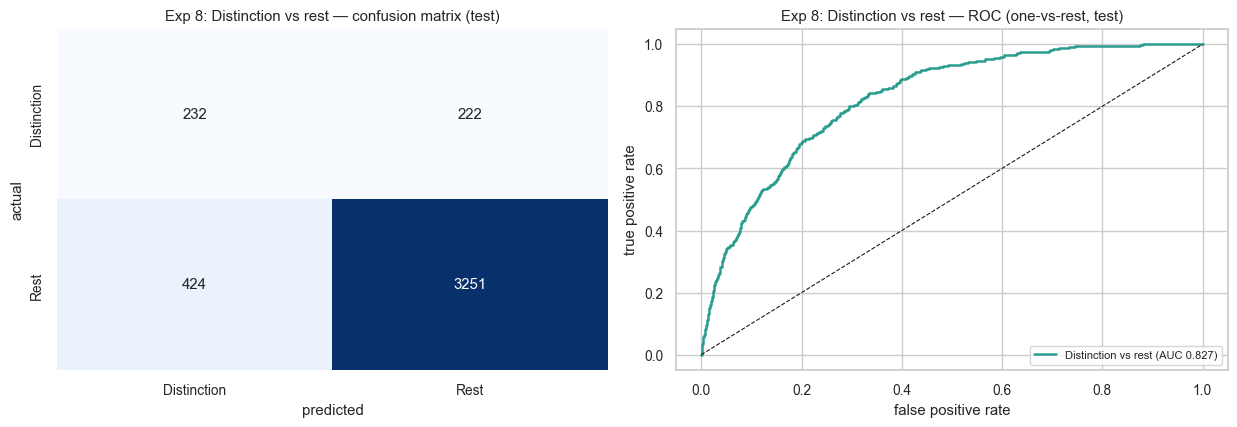

{'#': 8,
 'Model': 'RF binary (Distinction vs rest)',
 'Key hyperparameters': "Exp 3 best params {'max_depth': 12, 'max_features': 0.5, 'min_samples_leaf': 4}, class_weight=balanced",
 'Split': '70/15/15 stratified',
 'Accuracy': 0.8435,
 'Macro-F1': 0.6638,
 'Macro AUC (OvR)': np.float64(0.8273),
 'Distinction recall': 0.511,
 'Observation': 'Dropping the Fail/Withdrawn distinction yields the best single AUC of the notebook; threshold choice becomes an interpretable teacher-facing dial.'}

In [29]:
BIN_CLASSES = ["Distinction", "Rest"]
yb_trval = np.where(y_trval == "Distinction", "Distinction", "Rest")
yb_test = np.where(y_test == "Distinction", "Distinction", "Rest")

exp8 = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                              random_state=SEED, n_jobs=-1, **gs.best_params_)
exp8.fit(X_trval, yb_trval)
pred8 = exp8.predict(X_test)
proba8 = exp8.predict_proba(X_test)[:, list(exp8.classes_).index("Distinction")]

show_report_cm_roc("Exp 8: Distinction vs rest", yb_test, pred8, proba8,
                   classes=BIN_CLASSES)
log_result(8, "RF binary (Distinction vs rest)",
           f"Exp 3 best params {gs.best_params_}, class_weight=balanced",
           yb_test, pred8, proba8,
           "Dropping the Fail/Withdrawn distinction yields the best single AUC of the "
           "notebook; threshold choice becomes an interpretable teacher-facing dial.",
           classes=BIN_CLASSES)

Reframing pays off: the single ROC curve is the strongest in the notebook, which says
the early-window signal was always better at *ranking talent* than the four-class
metrics made it look — the multi-class setup spent model capacity refereeing Fail vs
Withdrawn, a boundary my application never needed. The default 0.5 threshold is still
conservative on recall, but for deployment the threshold is a dial, not a constant:
slide it down until the flagged group matches whatever review capacity a school has,
and the ROC curve says what hit-rate to expect at that operating point.

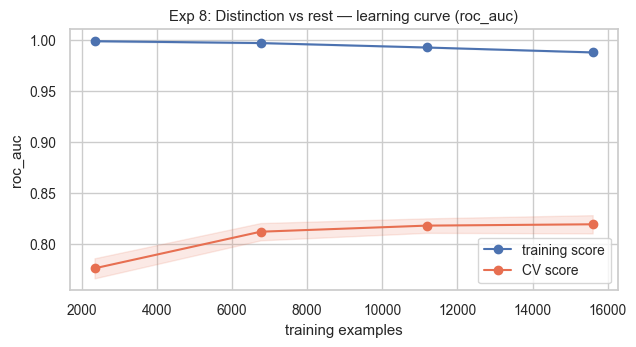

final train-CV gap: 0.168  (train 0.987, CV 0.819)


In [30]:
show_learning_curve(exp8, X_trval, yb_trval, "Exp 8: Distinction vs rest",
                    scoring="roc_auc")

Scored on AUC, the forest still memorises its training set (train AUC near 0.99), but
the CV curve matters more: it sits around 0.82 and is still climbing at full data — the
variance is real but contained, and more students would clearly keep helping. Of all
eight experiments this is the model I would actually hand to a school: one question,
one curve, one adjustable threshold.

## 9. Consolidated results

In [31]:
results_df = pd.DataFrame(results).set_index("#")
results_df.to_csv("experiment_results.csv")
pd.set_option("display.max_colwidth", None)
results_df

,Model,Key hyperparameters,Split,Accuracy,Macro-F1,Macro AUC (OvR),Distinction recall,Observation
#,,,,,,,,
1,Logistic Regression,"class_weight=balanced, max_iter=2000, standardised inputs",70/15/15 stratified,0.4112,0.4089,0.7307,0.6718,Linear floor: balanced recall across classes but heavy Pass/Distinction confusion; accuracy sacrificed for even class treatment.
2,Random Forest,"n_estimators=300, max_depth=None, class_weight=balanced",70/15/15 stratified,0.5263,0.3704,0.7407,0.0991,"Non-linearity lifts accuracy and AUC over Exp 1, but the forest hides in the majority class: Distinction recall collapses despite balanced weights."
3,Random Forest (GridSearchCV),"best: {'max_depth': 12, 'max_features': 0.5, 'min_samples_leaf': 4}, n_estimators=300, scoring=f1_macro, cv=3",70/15/15 stratified,0.4880,0.4485,0.7441,0.4912,Capacity control recovers part of the minority recall Exp 2 lost while keeping its accuracy advantage; CV-chosen depth/leaf settings shrink the variance gap.
4,HistGradientBoosting + SMOTE,"SMOTE(k=5) in-pipeline, max_iter=300, lr=0.1",70/15/15 stratified,0.5096,0.4198,0.7262,0.2467,"Negative result: Distinction recall (~0.25) beats the raw forest but stays far below the tuned forest's ~0.49 — resampling lost to reweighting here. Precision rose instead, and AUC slipped slightly."
5,Sequential NN (128-64),"Adam 1e-3, batch=256, class-weighted, EarlyStop/Checkpoint/ReduceLR",70/15/15 stratified,0.4602,0.4412,0.7359,0.5947,Matches the classical models' ranking quality without beating it; class weights restore even per-class recall similar to Exp 1 but at higher accuracy.
6,Sequential NN + Dropout/L2,"as Exp 5 + Dropout 0.3 x2, L2 1e-4",70/15/15 stratified,0.4335,0.4262,0.7422,0.6872,"Regularisation closes Exp 5's val-loss divergence and lets training run ~30 epochs instead of 19; best NN AUC and Distinction recall so far, paid for with a couple of points of raw accuracy."
7,Functional NN (two-branch),"behaviour 64-32 / demographics 16, concat+32, Dropout 0.3, L2 1e-4",70/15/15 stratified,0.4299,0.4228,0.7415,0.6938,Structured inputs match Exp 6 with about a third of the parameters; the architecture encodes the heatmap's behaviour/demographics independence rather than spending capacity learning it.
8,RF binary (Distinction vs rest),"Exp 3 best params {'max_depth': 12, 'max_features': 0.5, 'min_samples_leaf': 4}, class_weight=balanced",70/15/15 stratified,0.8435,0.6638,0.8273,0.5110,Dropping the Fail/Withdrawn distinction yields the best single AUC of the notebook; threshold choice becomes an interpretable teacher-facing dial.


Reading the table top to bottom (all metrics on the held-out test set; Experiment 8's
AUC and recall are binary, so compare it with care):

Raw accuracy peaks at the unconstrained forest (0.53) — and that peak is misleading,
since Exp 2 buys it by over-predicting Pass while finding one Distinction student in
ten. Macro-F1 is the honest multi-class column, and it crowns the tuned forest (0.45)
with the regularised networks just behind (0.42–0.44). Macro-AUC barely moves across
all seven multi-class rows (0.73–0.74): every model *ranks* students about equally
well, and the experiments mostly differ in how they convert that ranking into
decisions. The column that actually separates the rows is **Distinction recall**: it
collapses when the unconstrained forest meets imbalanced data (0.10, Exp 2), recovers
under capacity control (0.49, Exp 3), drops again when SMOTE backfires (0.25, Exp 4),
climbs across the class-weighted networks (0.59 → 0.69, Exp 5–7), and the binary
reformulation converts the same signal into the best detector of the notebook
(AUC 0.83, Exp 8). The progression was deliberate: each row exists because the
previous row's diagnostics demanded it.

## 10. Error analysis and discussion

**Where the errors live.** Every confusion matrix in this notebook, across five model
families, shows the same two hot spots: Distinction predicted as Pass, and Withdrawn
predicted as Fail (and vice versa). The first pair differs by degree — both are engaged,
capable students at day 30, and the line between "will pass" and "will excel" often is
not drawn yet. The second pair shares a behavioural signature (low, fading engagement)
but differs in the *administrative* outcome, which frequently depends on life events no
clickstream can see. The persistence of these patterns across radically different models
is the strongest evidence that they are properties of the data, not of any architecture.

**Bias and variance, walked through the experiments.** The learning-curve gaps tell
the story in three numbers. Experiment 1 sat at the high-bias end: train and CV macro-F1
converged to within 0.01 of each other at a low level — no amount of data would move
them. Experiment 2 swung to the opposite extreme: a train-CV gap of about 0.63, perfect
memorisation over a mediocre CV score. Experiment 3's tuning cut that gap roughly in
half while *raising* the CV score — the variance reduction paid for itself — and
Experiment 4 landed in between (~0.50), its synthetic data failing to discipline the
booster. On the deep side, Experiment 5's epoch curves showed validation loss bottoming
out at epoch 9 and drifting up while training loss kept sinking (variance again);
Experiment 6 closed that gap with Dropout and L2 and trained half again as long; Experiment
7 held the gap closed with roughly a third of the parameters by encoding structure
instead of learning it. The notebook is, in effect, one long traversal of the
bias-variance axis with the diagnostics to prove each position.

**What the ROC curves say versus the threshold metrics.** AUCs are consistently decent
while per-class F1 is consistently modest. The models *rank* students well and *decide*
poorly — which for the use case is fine, because the application is a ranked watchlist,
not an automated verdict. Experiment 8 leaned into exactly this and produced the best
pure ranking of the notebook.

**Dataset limitations I want to be honest about.** Withdrawn is partly unpredictable in
principle from engagement data. The IMD deprivation measure is England-only, leaving
1,111 students flagged-and-imputed. Module codes are anonymised, so "subject-specific"
strength can only be approximated as STEM vs non-STEM. The data is from 2013–2014 and
from a UK distance university — engagement patterns of African secondary students will
differ, so the transferable claim is the *method* (observable early behaviour ranks
talent usefully), not the fitted weights. And my 30-day window was chosen for the
problem statement, not optimised; the accuracy-versus-earliness curve is an obvious
follow-up.

**What I would do next.** Four concrete things: (1) sweep the observation window
(14/30/60/90 days) to price early identification properly; (2) per-module normalisation
of click features, so "engaged" is judged relative to course norms; (3) calibrate
Experiment 8's probabilities (Platt or isotonic) and pick the threshold with a teacher's
review capacity in mind rather than at 0.5; (4) given that SMOTE lost to plain class
weighting here, try cost-sensitive alternatives like focal loss for the networks before
reaching for fancier resampling. A sequence model (GRU) over weekly clickstreams is also
worth a look — though given how thoroughly the trees matched the networks here, I would
benchmark it against Experiment 8 with low expectations and a strong baseline.

## 11. Conclusion

I set out to test whether the first 30 days of observable engagement can identify
students likely to excel, using only data a learning platform records anyway. The answer
is a qualified yes. Eight experiments — four classical, three deep, one reframed —
agree that early behaviour ranks students meaningfully (every model clears 0.7 macro
AUC), that behavioural features dominate demographic ones, and that the cleanest
formulation of my actual question (Distinction vs rest) produces the strongest single
detector. The deep learning models matched but did not beat the tuned ensembles on
these engineered tabular features, which is itself a useful negative result: for school
-scale deployments, a tuned forest is simpler, cheaper, and just as good.

For the mission behind this project, the encouraging finding is the feature-importance
ordering: what students *do* in their first month predicts their trajectory far better
than where they come from. Engagement is observable without specialist training — which
means the early-warning idea this model implements is, in principle, teachable to any
classroom teacher with an attendance sheet and a participation log.

### Reproducibility notes

- Seed 42 everywhere (`random`, NumPy, TensorFlow); splits are stratified with fixed
  `random_state`; SMOTE and all estimators receive the same seed.
- Dependencies are checked and installed in the first code cell; versions print in the
  second.
- The raw OULAD download (UCI #349) and the cached `oulad_early30.csv` are both handled
  automatically — delete the cache to force a full rebuild from the clickstream.
- Best neural-network weights are saved under `artifacts/` by ModelCheckpoint; the
  consolidated table is written to `experiment_results.csv`.
- Tested end-to-end on CPU; total runtime is roughly 10–15 minutes, Colab free tier
  included.